In [1]:
#Giving sql connection

import mysql.connector
import pandas as pd

def fetch_data():
    try:
        # Establish a connection to the database
        connection = mysql.connector.connect(
            host='localhost',
            user='root',
            password='mysql123',
            database='sales'
        )

        # Create a cursor object
        cursor = connection.cursor()

        # Define the query
        query = 'SELECT * FROM sales.market_data;'

        # Execute the query
        cursor.execute(query)

        # Fetch all rows from the executed query
        results = cursor.fetchall()

        # Get column names from the cursor
        columns = [column[0] for column in cursor.description]

        # Create a DataFrame from the fetched data
        df = pd.DataFrame(results, columns=columns)

        return df

    except mysql.connector.Error as err:
        print(f"Error: {err}")
    finally:
        if connection.is_connected():
            cursor.close()
            connection.close()
            print("MySQL connection is closed")

if __name__ == "__main__":
    df = fetch_data()
    print(df)

MySQL connection is closed
        Sl no. District Name Market Name           Commodity  \
0            1        Amreli      Amreli  Cummin Seed(Jeera)   
1            2        Amreli      Amreli  Cummin Seed(Jeera)   
2            3        Amreli      Amreli  Cummin Seed(Jeera)   
3            4        Amreli      Amreli  Cummin Seed(Jeera)   
4            5        Amreli      Amreli  Cummin Seed(Jeera)   
...        ...           ...         ...                 ...   
1385149   9660       Khammam    Yellandu           Chili Red   
1385150   9661       Khammam    Yellandu           Chili Red   
1385151   9662       Khammam    Yellandu           Chili Red   
1385152   9663       Khammam    Yellandu           Chili Red   
1385153   9664       Khammam    Yellandu           Chili Red   

                    Variety Grade Min Price (Rs./Quintal)  \
0        Cummin Seed(Jeera)   FAQ                    5000   
1        Cummin Seed(Jeera)   FAQ                    6700   
2        Cummin Seed(

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1385154 entries, 0 to 1385153
Data columns (total 10 columns):
 #   Column                     Non-Null Count    Dtype 
---  ------                     --------------    ----- 
 0   Sl no.                     1385154 non-null  object
 1   District Name              1385154 non-null  object
 2   Market Name                1385154 non-null  object
 3   Commodity                  1385154 non-null  object
 4   Variety                    1385154 non-null  object
 5   Grade                      1385154 non-null  object
 6   Min Price (Rs./Quintal)    1385154 non-null  object
 7   Max Price (Rs./Quintal)    1385154 non-null  object
 8   Modal Price (Rs./Quintal)  1385154 non-null  object
 9   Price Date                 1385154 non-null  object
dtypes: object(10)
memory usage: 105.7+ MB


In [3]:
df = df[['District Name','Market Name','Commodity','Variety','Modal Price (Rs./Quintal)','Price Date']]
print(df)

        District Name Market Name           Commodity             Variety  \
0              Amreli      Amreli  Cummin Seed(Jeera)  Cummin Seed(Jeera)   
1              Amreli      Amreli  Cummin Seed(Jeera)  Cummin Seed(Jeera)   
2              Amreli      Amreli  Cummin Seed(Jeera)  Cummin Seed(Jeera)   
3              Amreli      Amreli  Cummin Seed(Jeera)  Cummin Seed(Jeera)   
4              Amreli      Amreli  Cummin Seed(Jeera)  Cummin Seed(Jeera)   
...               ...         ...                 ...                 ...   
1385149       Khammam    Yellandu           Chili Red                Bold   
1385150       Khammam    Yellandu           Chili Red                Bold   
1385151       Khammam    Yellandu           Chili Red                Bold   
1385152       Khammam    Yellandu           Chili Red                Bold   
1385153       Khammam    Yellandu           Chili Red                Bold   

        Modal Price (Rs./Quintal)   Price Date  
0                         

In [4]:
import pandas as pd

# Assuming df is your DataFrame and 'Price Date' is your date column

# 1. Convert to datetime if it's not already
df['Price Date'] = pd.to_datetime(df['Price Date'], errors='coerce')

# 2. Check the date range
print("Date range in the data:")
print("Minimum date:", df['Price Date'].min())
print("Maximum date:", df['Price Date'].max())

# 3. Sort the DataFrame by Price Date
df = df.sort_values('Price Date').reset_index(drop=True)

# 4. Create a new date range based on the DataFrame length
start_date = pd.Timestamp('2000-01-01')  # Arbitrary start date
new_date_range = pd.date_range(start=start_date, periods=len(df), freq='D')

# 5. Create a new column with the sequential dates
df['Sequential Price Date'] = new_date_range

print("\nFirst few rows of the DataFrame:")
print(df.head())

print("\nLast few rows of the DataFrame:")
print(df.tail())

Date range in the data:
Minimum date: 2021-01-01 00:00:00
Maximum date: 2024-07-01 00:00:00


OutOfBoundsDatetime: Cannot generate range with start=946684800000000000 and periods=1385154

In [41]:
# Replace 'Commodity' with the actual name of your column if it's different
specific_spice = 'Cinamon(Dalchini)'  # Replace with the spice you want to extract

# Extract the data for the specific spice
spice_df = df[df['Commodity'] == specific_spice]

print(f"Data for {specific_spice}:")
print(spice_df)

Data for Cinamon(Dalchini):
        District Name Market Name          Commodity Variety  \
382275         Mumbai      Mumbai  Cinamon(Dalchini)   Other   
382527         Mumbai      Mumbai  Cinamon(Dalchini)   Other   
382757         Mumbai      Mumbai  Cinamon(Dalchini)   Other   
383324         Mumbai      Mumbai  Cinamon(Dalchini)   Other   
383446         Mumbai      Mumbai  Cinamon(Dalchini)   Other   
...               ...         ...                ...     ...   
1384477        Mumbai      Mumbai  Cinamon(Dalchini)   Other   
1384601        Mumbai      Mumbai  Cinamon(Dalchini)   Other   
1384886        Mumbai      Mumbai  Cinamon(Dalchini)   Other   
1384959        Mumbai      Mumbai  Cinamon(Dalchini)   Other   
1385014        Mumbai      Mumbai  Cinamon(Dalchini)   Other   

        Modal Price (Rs./Quintal) Price Date  
382275                      60000 2022-01-21  
382527                      60000 2022-01-21  
382757                      60000 2022-01-21  
383324         

In [42]:
def clean_price(price_str):
    try:
        # Split the string into individual prices and convert to float
        prices = [float(price) for price in price_str.split('0') if price]
        return prices
    except:
        return []

In [43]:
import pandas as pd
import numpy as np
import os
from calendar import monthrange
from datetime import datetime

def clean_price(price_str):
    try:
        prices = [float(price) for price in price_str.split('0') if price]
        return prices
    except:
        return []

def create_commodity_table(df, commodity):
    spice_df_df = df[df['Commodity'] == commodity].copy()
    spice_df['Price Date'] = pd.to_datetime(spice_df['Price Date'])
    spice_df['Cleaned Prices'] = spice_df['Modal Price (Rs./Quintal)'].apply(clean_price)
    
    def process_group(group):
        monthly_data = []
        
        for (year, month), month_data in group.groupby([group['Price Date'].dt.year, group['Price Date'].dt.month]):
            if not month_data.empty:
                all_prices = [price for prices in month_data['Cleaned Prices'] for price in prices]
                
                if all_prices:
                    start_date = month_data['Price Date'].min()
                    end_date = month_data['Price Date'].max()
                    days_in_month = monthrange(year, month)[1]
                    available_days = month_data['Price Date'].nunique()
                    null_days = days_in_month - available_days
                    
                    monthly_data.append({
                        'Start Date': start_date,
                        'End Date': end_date,
                        'No. of Data pts': days_in_month,
                        'available data pts': available_days,
                        'null values': null_days,
                        '% of null values': (null_days / days_in_month) * 100
                    })
        
        return pd.DataFrame(monthly_data)
    
    grouped = spice_df.groupby(['District Name', 'Market Name', 'Commodity', 'Variety'])
    table = grouped.apply(process_group).reset_index()
    
    # Reorder and select final columns
    table = table[['District Name', 'Market Name', 'Commodity', 'Variety', 'Start Date', 'End Date',
                   'No. of Data pts', 'available data pts', 'null values', '% of null values']]
    
    return table

# Function to try saving the file
def try_save_file(path, result_table, selected_commodity):
    try:
        os.makedirs(os.path.dirname(path), exist_ok=True)
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        filename = f"{selected_commodity}_{timestamp}_table.csv"
        full_path = os.path.join(path, filename)
        result_table.to_csv(full_path, index=False)
        print(f"\nTable for {selected_commodity} saved to {full_path}")
        return True
    except Exception as e:
        print(f"Failed to save to {path}. Error: {e}")
        return False

# Get unique commodities
unique_commodities = df['Commodity'].unique()

# Display available commodities
print("Available commodities:")
for i, commodity in enumerate(unique_commodities, 1):
    print(f"{i}. {commodity}")

# Get user input for commodity selection
while True:
    try:
        choice = int(input("\nEnter the number of the commodity you want to process: "))
        if 1 <= choice <= len(unique_commodities):
            selected_commodity = unique_commodities[choice - 1]
            break
        else:
            print("Invalid choice. Please enter a number from the list.")
    except ValueError:
        print("Invalid input. Please enter a number.")

# Create the table for the selected commodity
result_table = create_commodity_table(df, selected_commodity)

# Specify save paths
primary_save_path = r'D:\MBA\Internship\forecasting csv'
desktop_path = os.path.join(os.path.expanduser('~'), 'Desktop')
current_dir_path = os.getcwd()

# Try saving to different locations
if not try_save_file(primary_save_path, result_table, selected_commodity):
    print("Attempting to save to desktop...")
    if not try_save_file(desktop_path, result_table, selected_commodity):
        print("Attempting to save to current directory...")
        if not try_save_file(current_dir_path, result_table, selected_commodity):
            print("Failed to save the file to any location.")
            print("Displaying data in console instead.")
            print("\nAll data:")
            print(result_table.to_string())
        else:
            print("File saved in the current directory.")
    else:
        print("File saved on the desktop.")
else:
    print("File saved in the primary location.")

# Display the first few rows of the table
print("\nFirst few rows of the table:")
print(result_table.head())

# Optionally, display all data
user_input = input("Do you want to display all data in the console? (y/n): ")
if user_input.lower() == 'y':
    print("\nAll data:")
    print(result_table.to_string())

Available commodities:
1. Black pepper
2. Coriander(Leaves)
3. Turmeric
4. Turmeric (raw)
5. Cummin Seed(Jeera)
6. Nutmeg
7. Cardamoms
8. Chili Red
9. Ajwan
10. Cloves
11. Bay leaf (Tejpatta)
12. Mace
13. Cinamon(Dalchini)


C:\Users\soura\AppData\Local\Temp\ipykernel_23460\2146402623.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spice_df['Price Date'] = pd.to_datetime(spice_df['Price Date'])
C:\Users\soura\AppData\Local\Temp\ipykernel_23460\2146402623.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spice_df['Cleaned Prices'] = spice_df['Modal Price (Rs./Quintal)'].apply(clean_price)
C:\Users\soura\AppData\Local\Temp\ipykernel_23460\2146402623.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the groupin


Table for Cinamon(Dalchini) saved to D:\MBA\Internship\forecasting csv\Cinamon(Dalchini)_20240712_163538_table.csv
File saved in the primary location.

First few rows of the table:
  District Name Market Name          Commodity            Variety Start Date  \
0    Chhindwara  Chhindwara  Cinamon(Dalchini)  Cinamon(Dalchini) 2023-05-15   
1    Chhindwara  Chhindwara  Cinamon(Dalchini)  Cinamon(Dalchini) 2023-10-31   
2    Chhindwara  Chhindwara  Cinamon(Dalchini)              Other 2023-06-05   
3    Chhindwara  Chhindwara  Cinamon(Dalchini)              Other 2023-07-31   
4    Chhindwara  Chhindwara  Cinamon(Dalchini)              Other 2023-08-02   

    End Date  No. of Data pts  available data pts  null values  \
0 2023-05-15               31                   1           30   
1 2023-10-31               31                   1           30   
2 2023-06-30               30                   5           25   
3 2023-07-31               31                   1           30   
4 2023-

In [ ]:
commodity = 'Cinamon(Dalchini)'
sequenced_df = df[df['Commodity'] == commodity].copy()

# 2. Preprocess the Data
sequenced_df['Price Date'] = pd.to_datetime(sequenced_df['Price Date'])
sequenced_df.sort_values(by='Price Date', inplace=True)

# 3. Group and Sequence the Data
grouped = sequenced_df.groupby(['District Name', 'Market Name', 'Commodity', 'Variety'])

# Create an empty DataFrame to store the results
sequenced_df = pd.DataFrame()

# Iterate over each group and store the sequenced data
for name, group in grouped:
    # Ensure the data is sorted by 'pricedate'
    group = group.sort_values(by='Price Date')
    
    # Append the sequenced group to the final DataFrame
    sequenced_df = pd.concat([spice_df, group])

# Reset index for the final DataFrame
sequenced_df.reset_index(drop=True, inplace=True)

# Display the result
print(sequenced_df.head())

# Optionally save to a new CSV file
sequenced_df.to_csv('sequenced_data.csv', index=False)

  District Name Market Name          Commodity Variety  \
0        Mumbai      Mumbai  Cinamon(Dalchini)   Other   
1        Mumbai      Mumbai  Cinamon(Dalchini)   Other   
2        Mumbai      Mumbai  Cinamon(Dalchini)   Other   
3        Mumbai      Mumbai  Cinamon(Dalchini)   Other   
4        Mumbai      Mumbai  Cinamon(Dalchini)   Other   

  Modal Price (Rs./Quintal) Price Date  
0                     60000 2022-01-21  
1                     60000 2022-01-21  
2                     60000 2022-01-21  
3                     60000 2022-01-21  
4                     60000 2022-01-21  


In [ ]:
# Rename one or more columns
sequenced_df = sequenced_df.rename(columns={'Modal Price (Rs./Quintal)': 'Modal Price'})

In [ ]:
sequenced_df

,District Name,Market Name,Commodity,Variety,Modal Price,Price Date
0,Mumbai,Mumbai,Cinamon(Dalchini),Other,60000,2022-01-21
1,Mumbai,Mumbai,Cinamon(Dalchini),Other,60000,2022-01-21
2,Mumbai,Mumbai,Cinamon(Dalchini),Other,60000,2022-01-21
3,Mumbai,Mumbai,Cinamon(Dalchini),Other,60000,2022-01-21
4,Mumbai,Mumbai,Cinamon(Dalchini),Other,60000,2022-01-21
...,...,...,...,...,...,...
4783,Mumbai,Mumbai,Cinamon(Dalchini),Other,17500,2024-07-01
4784,Mumbai,Mumbai,Cinamon(Dalchini),Other,17500,2024-07-01
4785,Mumbai,Mumbai,Cinamon(Dalchini),Other,17500,2024-07-01
4786,Mumbai,Mumbai,Cinamon(Dalchini),Other,17500,2024-07-01


######### Exploratory Data Analysis ############

In [ ]:
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

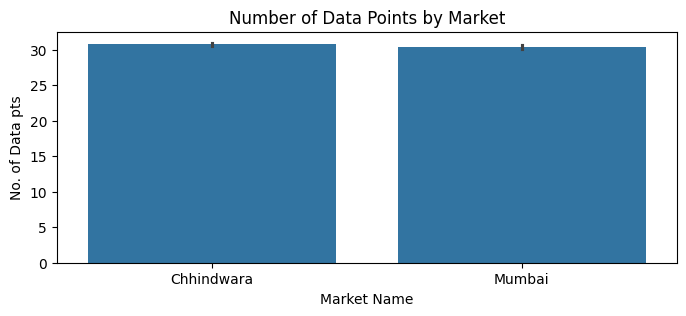

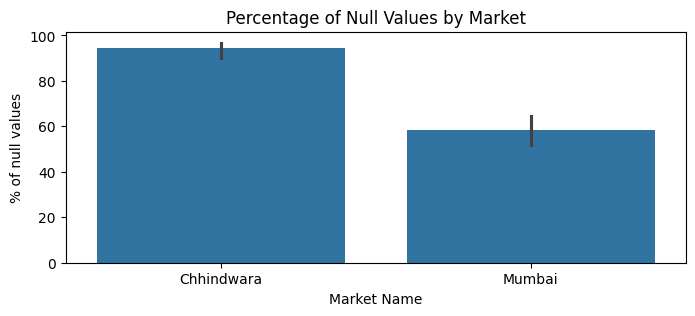

In [ ]:
# Visualize the data
plt.figure(figsize=(8, 3))
sns.barplot(x='Market Name', y='No. of Data pts', data=result_table)
plt.title('Number of Data Points by Market')
plt.show()

plt.figure(figsize=(8, 3))
sns.barplot(x='Market Name', y='% of null values', data=result_table)
plt.title('Percentage of Null Values by Market')
plt.show()

In [ ]:
# Descriptive statistics
descriptive_stats =result_table .describe()
print("Descriptive statistics:")
print(descriptive_stats)


Descriptive statistics:
                          Start Date                       End Date  \
count                             37                             37   
mean   2023-04-23 20:06:29.189189120  2023-05-14 05:50:16.216216320   
min              2022-01-21 00:00:00            2022-01-28 00:00:00   
25%              2022-10-01 00:00:00            2022-10-08 00:00:00   
50%              2023-06-01 00:00:00            2023-06-30 00:00:00   
75%              2023-10-31 00:00:00            2023-10-31 00:00:00   
max              2024-07-01 00:00:00            2024-07-01 00:00:00   
std                              NaN                            NaN   

       No. of Data pts  available data pts  null values  % of null values  
count        37.000000           37.000000    37.000000         37.000000  
mean         30.486486           10.918919    19.567568         64.071212  
min          28.000000            1.000000    10.000000         32.258065  
25%          30.000000          

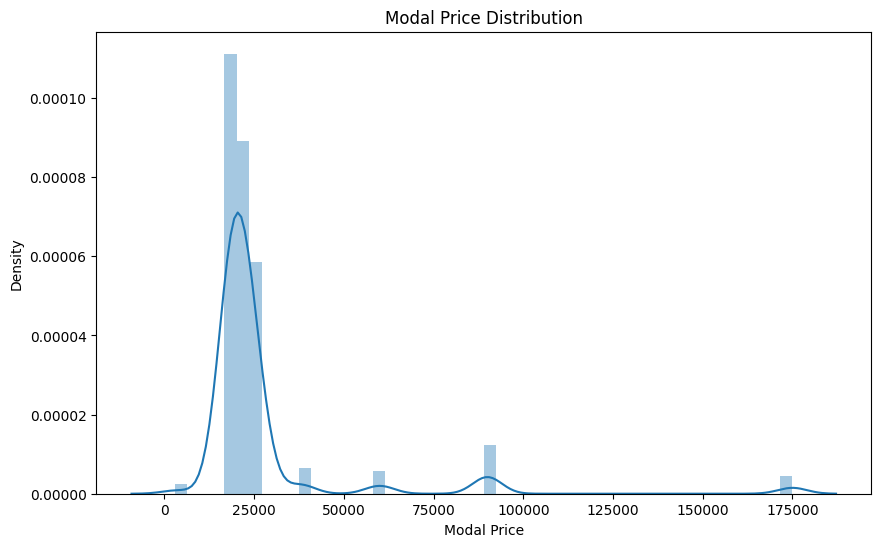

In [ ]:
# Modal Price distribution
plt.figure(figsize=(10, 6))
sns.distplot(sequenced_df['Modal Price'])
plt.title('Modal Price Distribution')
plt.show()

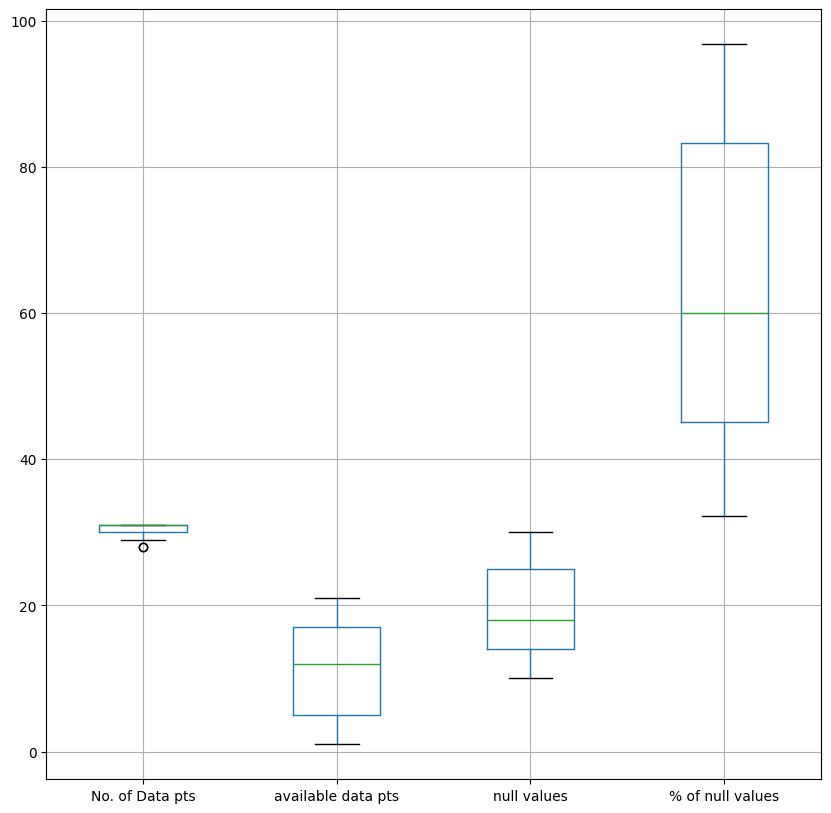

In [ ]:
result_table.boxplot(figsize=(10, 10))
plt.show()

In [ ]:
sequenced_df['Modal Price'] = pd.to_numeric(sequenced_df['Modal Price'], errors='coerce')

In [ ]:
print(sequenced_df['Modal Price'].dtype)

int64


In [ ]:
#sequenced_df = sequenced_df.dropna(subset=['Modal Price'])

In [ ]:
z_scores = np.abs(stats.zscore(sequenced_df['Modal Price']))

In [ ]:
import numpy as np
from scipy import stats
import pandas as pd

# Convert 'Modal Price' to numeric and remove any rows with non-numeric values
sequenced_df['Modal Price'] = pd.to_numeric(sequenced_df['Modal Price'], errors='coerce')
sequenced_df = sequenced_df.dropna(subset=['Modal Price'])

# Check for outliers using the Z-score method
z_scores = np.abs(stats.zscore(sequenced_df['Modal Price']))
outliers = sequenced_df[z_scores > 3]

print("Outliers (Z-score > 3):")
print(outliers)

# Calculate descriptive statistics for each commodity
commodity_stats = sequenced_df.groupby('Commodity')['Modal Price'].describe()

print("\nDescriptive statistics by commodity:")
print(commodity_stats)

Outliers (Z-score > 3):
     District Name Market Name          Commodity Variety  Modal Price  \
150         Mumbai      Mumbai  Cinamon(Dalchini)   Other       175000   
151         Mumbai      Mumbai  Cinamon(Dalchini)   Other       175000   
152         Mumbai      Mumbai  Cinamon(Dalchini)   Other       175000   
153         Mumbai      Mumbai  Cinamon(Dalchini)   Other       175000   
154         Mumbai      Mumbai  Cinamon(Dalchini)   Other       175000   
...            ...         ...                ...     ...          ...   
2791        Mumbai      Mumbai  Cinamon(Dalchini)   Other       175000   
2792        Mumbai      Mumbai  Cinamon(Dalchini)   Other       175000   
2793        Mumbai      Mumbai  Cinamon(Dalchini)   Other       175000   
2794        Mumbai      Mumbai  Cinamon(Dalchini)   Other       175000   
2795        Mumbai      Mumbai  Cinamon(Dalchini)   Other       175000   

     Price Date  
150  2022-03-30  
151  2022-03-30  
152  2022-03-30  
153  2022-03-30

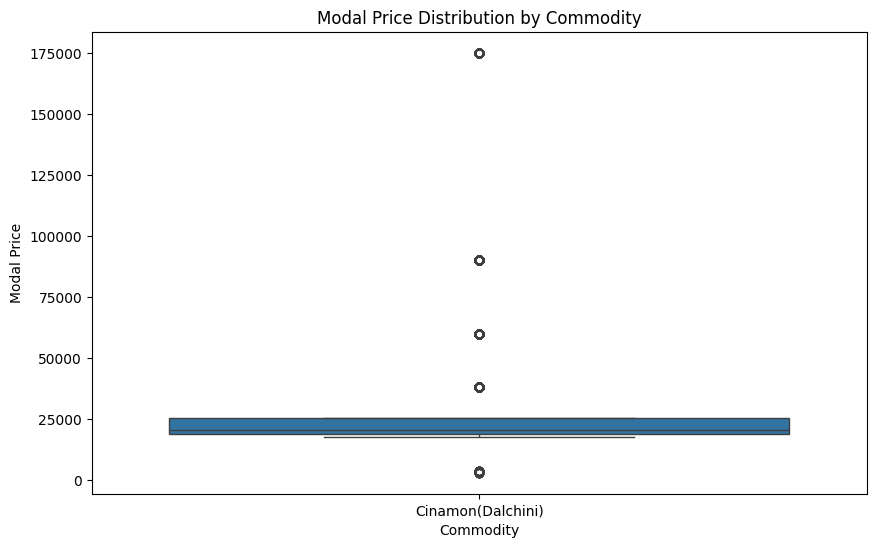

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Commodity', y='Modal Price', data=sequenced_df)
plt.title('Modal Price Distribution by Commodity')
plt.show()

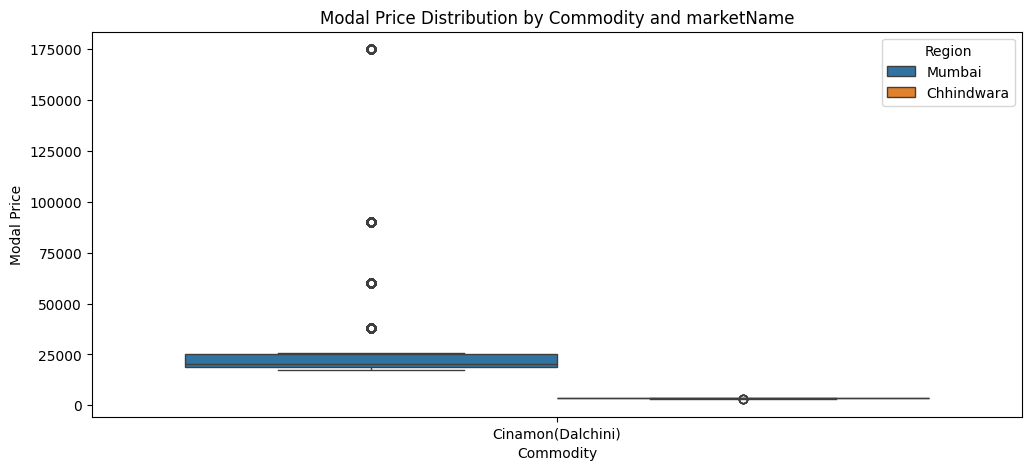

In [ ]:
# Generate boxplots for modal price by commodity and region
plt.figure(figsize=(12, 5))
sns.boxplot(x='Commodity', y='Modal Price', hue='Market Name', data=sequenced_df)
plt.title('Modal Price Distribution by Commodity and marketName')
plt.legend(title='Region', loc='upper right')
plt.show()

In [ ]:
# Check for missing values
print(sequenced_df.isnull().sum())

# Handling missing values (example: filling missing prices with the mean)
sequenced_df['Modal Price'].fillna(sequenced_df['Modal Price'].mean(), inplace=True)

District Name    0
Market Name      0
Commodity        0
Variety          0
Modal Price      0
Price Date       0
dtype: int64


In [ ]:
print(sequenced_df['Modal Price'].isnull().sum())

# check for null values in the 'commodity' column
print(sequenced_df['Commodity'].isnull().sum())

# check for null values in the 'market Name' column
print(sequenced_df['Price Date'].isnull().sum())


0
0
0


In [ ]:
print(sequenced_df.columns)

Index(['District Name', 'Market Name', 'Commodity', 'Variety', 'Modal Price',
       'Price Date'],
      dtype='object')


In [ ]:
# Rename one or more columns
sequenced_df = sequenced_df.rename(columns={'Modal Price (Rs./Quintal)': 'Modal Price'})

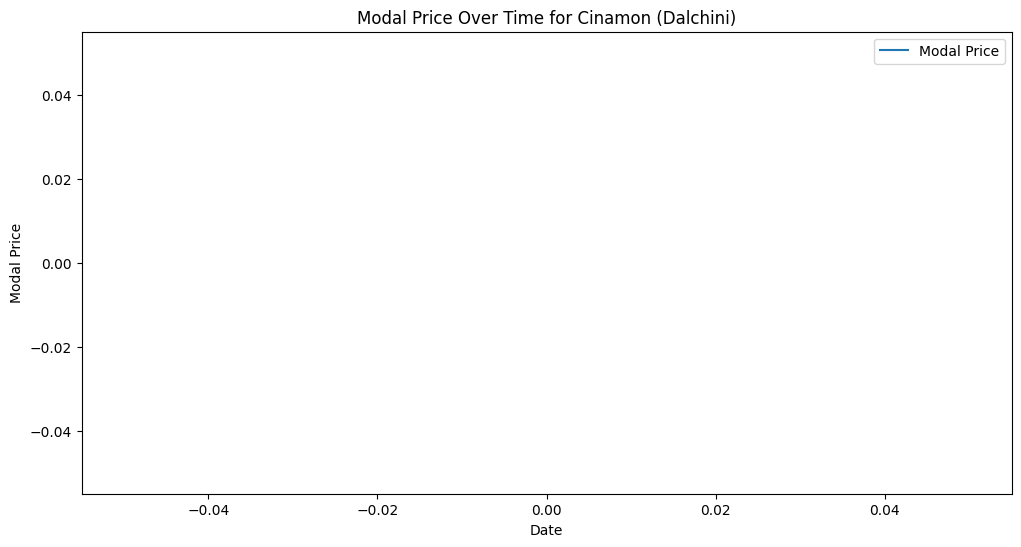

In [ ]:

#result_table.set_index('Start Date', inplace=True)

# Plotting the modalPrice over time for a specific commodity
commodity = 'Cinamon (Dalchini)'  # Replace with your commodity
sequenced_df = sequenced_df[sequenced_df['Commodity'] == commodity]

plt.figure(figsize=(12, 6))
plt.plot(sequenced_df.index, sequenced_df['Modal Price'], label='Modal Price')
plt.title(f'Modal Price Over Time for {commodity}')
plt.xlabel('Date')
plt.ylabel('Modal Price')
plt.legend()
plt.show()

In [ ]:
sequenced_df.columns

Index(['District Name', 'Market Name', 'Commodity', 'Variety', 'Modal Price',
       'Price Date'],
      dtype='object')

In [ ]:
columns_to_drop = ['Market Name']
for col in columns_to_drop:
    if col in sequenced_df.columns:
        sequenced_df.drop(columns=[col], inplace=True)

In [ ]:
sequenced_df.columns

Index(['District Name', 'Commodity', 'Variety', 'Modal Price', 'Price Date'], dtype='object')

In [ ]:
commodity = 'Cinamon(Dalchini)'
sequenced_df = df[df['Commodity'] == commodity].copy()

# 2. Preprocess the Data
sequenced_df['Price Date'] = pd.to_datetime(sequenced_df['Price Date'])
sequenced_df.sort_values(by='Price Date', inplace=True)

# 3. Group and Sequence the Data
grouped = sequenced_df.groupby(['District Name', 'Market Name', 'Commodity', 'Variety'])

# Create an empty DataFrame to store the results
sequenced_df = pd.DataFrame()

# Iterate over each group and store the sequenced data
for name, group in grouped:
    # Ensure the data is sorted by 'pricedate'
    group = group.sort_values(by='Price Date')
    
    # Append the sequenced group to the final DataFrame
    sequenced_df = pd.concat([spice_df, group])

# Reset index for the final DataFrame
sequenced_df.reset_index(drop=True, inplace=True)

# Display the result
print(sequenced_df.head())

# Optionally save to a new CSV file
sequenced_df.to_csv('sequenced_data.csv', index=False)

  District Name Market Name          Commodity Variety  \
0        Mumbai      Mumbai  Cinamon(Dalchini)   Other   
1        Mumbai      Mumbai  Cinamon(Dalchini)   Other   
2        Mumbai      Mumbai  Cinamon(Dalchini)   Other   
3        Mumbai      Mumbai  Cinamon(Dalchini)   Other   
4        Mumbai      Mumbai  Cinamon(Dalchini)   Other   

  Modal Price (Rs./Quintal) Price Date  
0                     60000 2022-01-21  
1                     60000 2022-01-21  
2                     60000 2022-01-21  
3                     60000 2022-01-21  
4                     60000 2022-01-21  


In [ ]:
# Rename one or more columns
sequenced_df = sequenced_df.rename(columns={'Modal Price (Rs./Quintal)': 'Modal Price'})

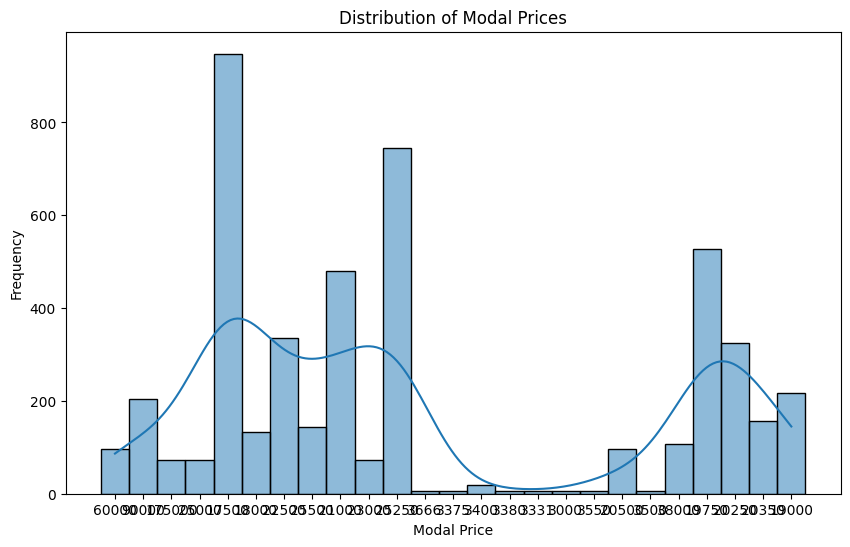

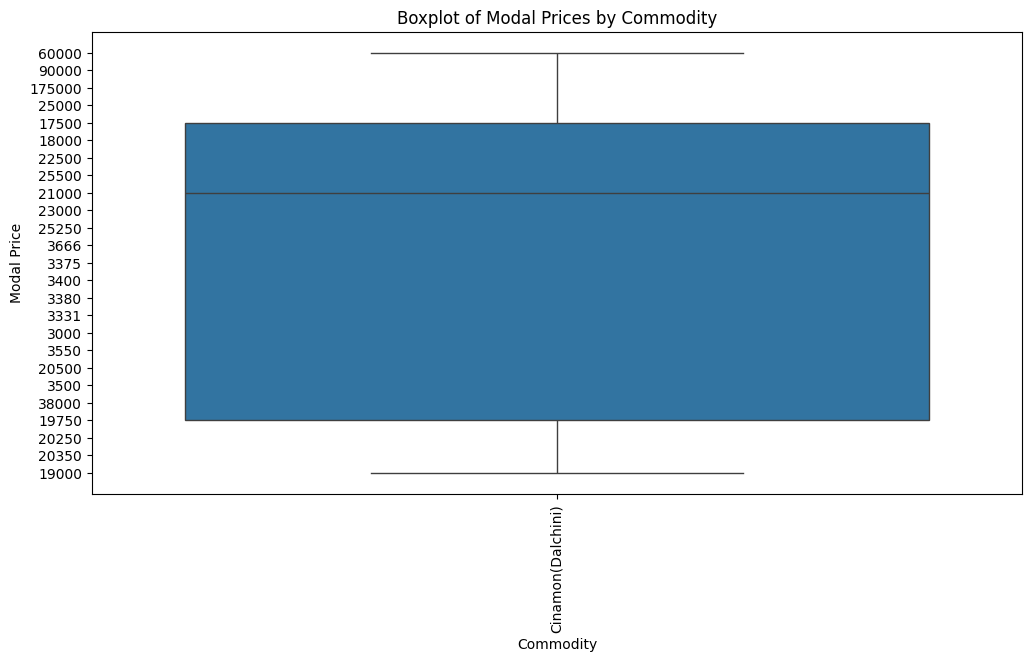

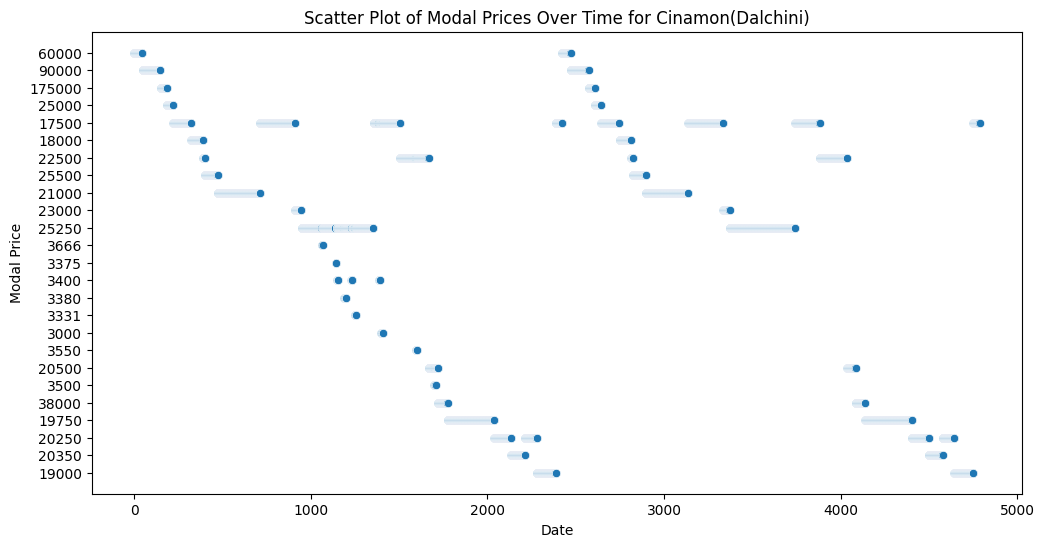

In [ ]:
# Distribution of modalPrice
plt.figure(figsize=(10, 6))
sns.histplot(sequenced_df['Modal Price'], bins=30, kde=True)
plt.title('Distribution of Modal Prices')
plt.xlabel('Modal Price')
plt.ylabel('Frequency')
plt.show()

# Boxplot of modalPrice by commodity
plt.figure(figsize=(12, 6))
sns.boxplot(x='Commodity', y='Modal Price', data=sequenced_df)
plt.title('Boxplot of Modal Prices by Commodity')
plt.xlabel('Commodity')
plt.ylabel('Modal Price')
plt.xticks(rotation=90)
plt.show()

# Scatter plot of modalPrice over time
plt.figure(figsize=(12, 6))
sns.scatterplot(x=sequenced_df.index, y='Modal Price', data=sequenced_df)
plt.title(f'Scatter Plot of Modal Prices Over Time for {commodity}')
plt.xlabel('Date')
plt.ylabel('Modal Price')
plt.show()

##Seasonal Decomposition

##Stationarity Check

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
adf_result = adfuller(sequenced_df['Modal Price'])

print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
for key, value in adf_result[4].items():
    print('Critical Value (%s): %.3f' % (key, value))

ADF Statistic: -5.678036824982392
p-value: 8.613864671346881e-07
Critical Value (1%): -3.432
Critical Value (5%): -2.862
Critical Value (10%): -2.567


##Time Series Modeling

In [ ]:
sequenced_df.index = pd.date_range(start='2021-01-01', periods=len(sequenced_df), freq='D')

In [ ]:
print(sequenced_df['Modal Price'].dtype)
print(sequenced_df['Modal Price'].unique())

object
['60000' '90000' '175000' '25000' '17500' '18000' '22500' '25500' '21000'
 '23000' '25250' '3666' '3375' '3400' '3380' '3331' '3000' '3550' '20500'
 '3500' '38000' '19750' '20250' '20350' '19000']


In [ ]:
sequenced_df['Modal Price'] = pd.to_numeric(sequenced_df['Modal Price'], errors='coerce')

In [ ]:
sequenced_df = sequenced_df.dropna(subset=['Modal Price'])

In [ ]:
sequenced_df['Modal Price'] = sequenced_df['Modal Price'].astype(float)

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
# Fit an ARIMA model
model = ARIMA(sequenced_df['Modal Price'], order=(1, 1, 1))
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())

# Forecast
forecast = model_fit.forecast(steps=30)  # Forecasting next 30 days
print(forecast)

                               SARIMAX Results                                
Dep. Variable:            Modal Price   No. Observations:                 4788
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -46711.459
Date:                Fri, 12 Jul 2024   AIC                          93428.918
Time:                        13:11:18   BIC                          93448.339
Sample:                    01-01-2021   HQIC                         93435.739
                         - 02-09-2034                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0699      0.090     -0.774      0.439      -0.247       0.107
ma.L1         -0.0312      0.091     -0.342      0.732      -0.210       0.148
sigma2      1.751e+07   1.83e+04    958.665      0.0

In [ ]:
# Assuming sequenced_df is your full dataset
train_size = int(len(sequenced_df) * 0.7)  # Use 70% of data for training
train = sequenced_df[:train_size]
test = sequenced_df[train_size:]

In [ ]:
model = ARIMA(train['Modal Price'], order=(1, 1, 1))
model_fit = model.fit()

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

Mean Absolute Error (MAE): 3301.461377870564


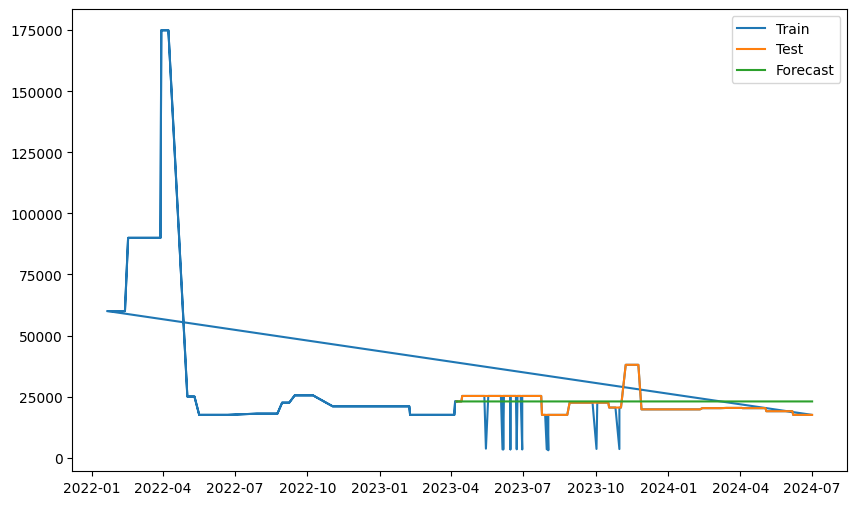

In [ ]:
# Forecasting
n_forecast = len(test)
forecast = model_fit.get_forecast(steps=n_forecast)
forecast_index = test.index
forecast_values = forecast.predicted_mean
forecast_values.index = forecast_index

# Calculate MAE
mae = mean_absolute_error(test['Modal Price'], forecast_values)
print(f'Mean Absolute Error (MAE): {mae}')

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(train['Price Date'], train['Modal Price'], label='Train')
plt.plot(test['Price Date'], test['Modal Price'], label='Test')
plt.plot(test['Price Date'], forecast_values, label='Forecast')
plt.legend()

plt.show()

ARIMA RMSE: 4247.487283732551
Mean Absolute Error (MAE): 3301.461377870564


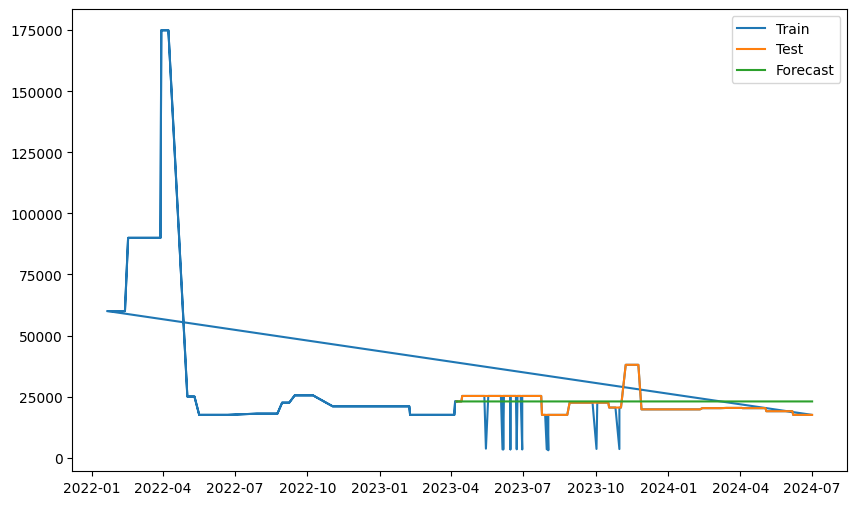

In [ ]:
# Assuming sequenced_df is your full dataset
train_size = int(len(sequenced_df) * 0.7)  # Use 70% of data for training
train = sequenced_df[:train_size]
test = sequenced_df[train_size:]

# Fit ARIMA model
model = ARIMA(train['Modal Price'], order=(1, 1, 1))
model_fit = model.fit()

# Forecast
n_forecast = len(test)
forecast = model_fit.get_forecast(steps=n_forecast)
arima_forecast_values = forecast.predicted_mean

# Define actual values
actual_values = test['Modal Price']

# Calculate RMSE
arima_rmse = mean_squared_error(actual_values, arima_forecast_values, squared=False)
print(f'ARIMA RMSE: {arima_rmse}')

# Calculate MAE
mae = mean_absolute_error(actual_values, arima_forecast_values)
print(f'Mean Absolute Error (MAE): {mae}')

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(train['Price Date'], train['Modal Price'], label='Train')
plt.plot(test['Price Date'], actual_values, label='Test')
plt.plot(test['Price Date'], arima_forecast_values, label='Forecast')
plt.legend()
plt.show()

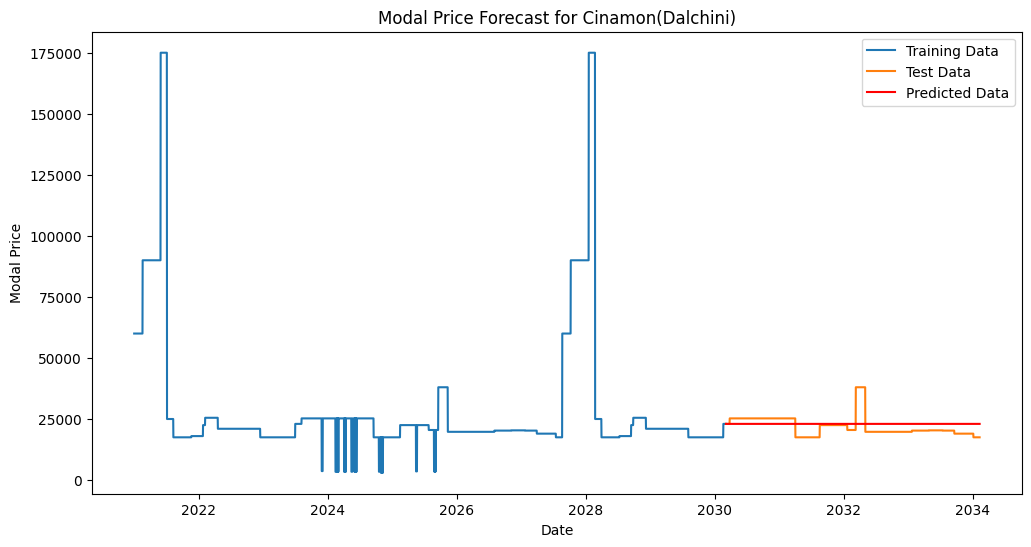

In [ ]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['Modal Price'], label='Training Data')
plt.plot(test.index, test['Modal Price'], label='Test Data')
plt.plot(test.index, predictions, label='Predicted Data', color='red')
plt.title(f'Modal Price Forecast for {commodity}')
plt.xlabel('Date')
plt.ylabel('Modal Price')
plt.legend()
plt.show()

Mean Absolute Error: 3301.46
RMSE value: 18041148.23


d:\MBA\.conda\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


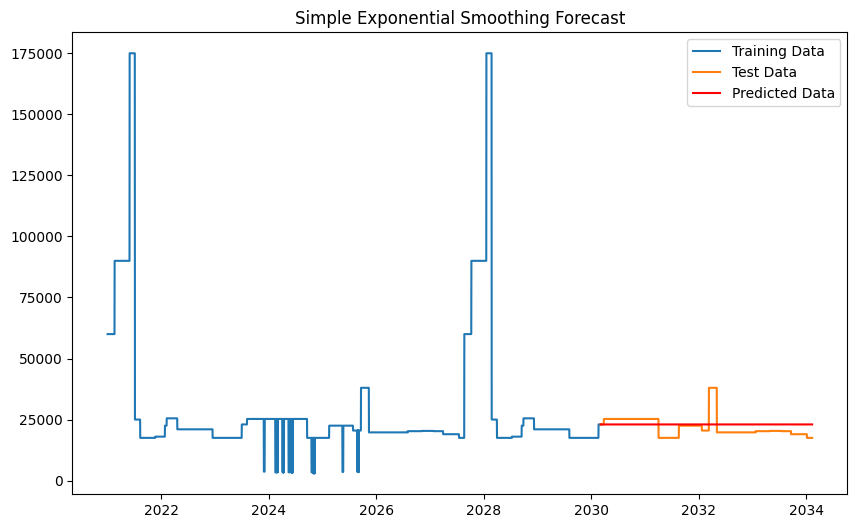

In [ ]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
# Fit Simple Exponential Smoothing model
if len(train) > 0:
    model = SimpleExpSmoothing(train['Modal Price']).fit()
    predictions = model.predict(start=test.index[0], end=test.index[-1])
else:
    print("Error: Training dataset is empty.")

# Calculate MAE
mae = mean_absolute_error(test['Modal Price'], predictions)
print(f'Mean Absolute Error: {mae:.2f}')

# Calculate RMSE
RMSE= mean_squared_error(test['Modal Price'],predictions)
print(f'RMSE value: {RMSE:.2f}')

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(train.index, train['Modal Price'], label='Training Data')
plt.plot(test.index, test['Modal Price'], label='Test Data')
plt.plot(test.index, predictions, label='Predicted Data', color='red')
plt.legend()
plt.title('Simple Exponential Smoothing Forecast')
plt.show()

Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0128
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0022
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0029
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0012  
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0019
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0012
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0013
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014
Epoch 9/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0014
Epoch 10/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.3396e-04
Epoch 11/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0010   
Epoch 12/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.9561e-04
Epoch 13/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.9440e-04
Epoch 14/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0013
Epoch 15/50
105/105 ━━━━━━━━━━━━━━━━━━━━

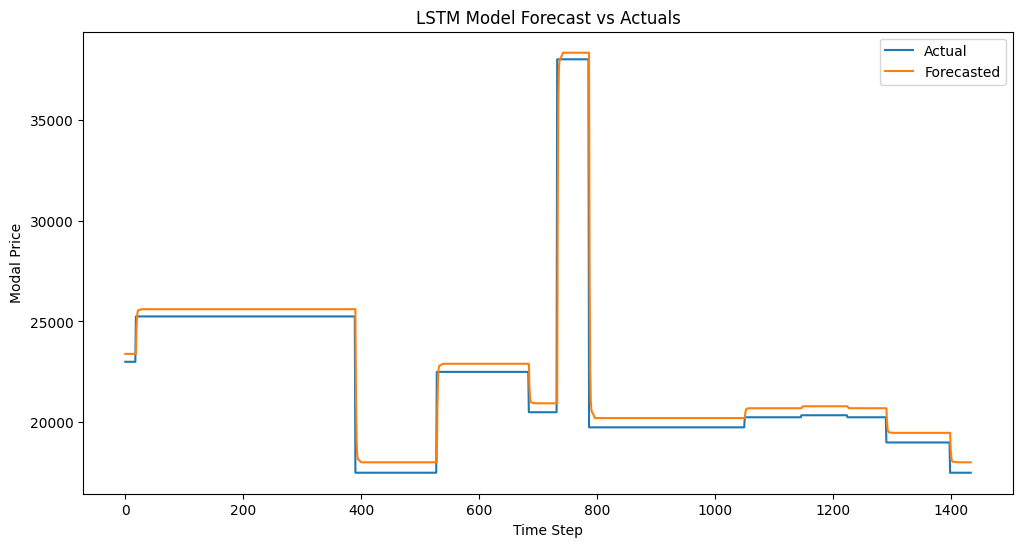

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np
import matplotlib.pyplot as plt

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(sequenced_df['Modal Price'].values.reshape(-1, 1))

# Create sequences
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        seq = data[i:i + seq_length]
        label = data[i + seq_length]
        sequences.append((seq, label))
    return sequences

seq_length = 10
sequences = create_sequences(scaled_data, seq_length)
X, y = zip(*sequences)
X = np.array(X)
y = np.array(y)

# Split into train and test sets
train_size = int(len(X) * 0.7)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Define and fit the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(seq_length, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, epochs=50, batch_size=32)

# Forecasting
lstm_forecast_values = model.predict(X_test)
lstm_forecast_values = scaler.inverse_transform(lstm_forecast_values)
actual = scaler.inverse_transform(y_test)

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(actual, lstm_forecast_values)
print(f'Mean Absolute Error (MAE): {mae}')

# Calculate RMSE value
lstm_rmse = mean_squared_error(actual, lstm_forecast_values, squared=False)
print(f'LSTM RMSE: {lstm_rmse}')

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(range(len(actual)), actual, label='Actual')
plt.plot(range(len(lstm_forecast_values)), lstm_forecast_values, label='Forecasted')
plt.xlabel('Time Step')
plt.ylabel('Modal Price')
plt.title('LSTM Model Forecast vs Actuals')
plt.legend()
plt.show()